# Veri Yükleme ve Fiziksel Analiz

## fdfsfsdf

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görsellik ayarları (Hackathon sunumu için şık bir tema)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)

# 1. Veriyi Yükle (CSV dosyanın adını buraya gir)
df = pd.read_csv("radiation_dataset.csv")

print(f"Veri Seti Boyutu: {df.shape[0]} Yörünge Simülasyonu, {df.shape[1]} Özellik")

# 2. Fiziksel Mantık Kontrolü (Sanity Check)
print("\n--- Fiziksel Mantık Kontrolleri ---")

# Kural 1: GCR (Galaktik Kozmik Işınlar) hiçbir yörüngede SIFIR olamaz.
min_gcr = df['p_gcr_fluence_10.0MeV'].min()
print(f"Minimum GCR Dozu: {min_gcr:.2e} -> {'BAŞARILI' if min_gcr > 0 else 'HATA: GCR Sıfır!'}")

# Kural 2: LEO'da SPE sıfıra yakın olmalı, GEO'da maksimum olmalı.
leo_spe = df[df['altitude_km'] < 1000]['p_spe_fluence_10.0MeV'].mean()
geo_spe = df[df['altitude_km'] > 30000]['p_spe_fluence_10.0MeV'].mean()
print(f"LEO Ortalama SPE: {leo_spe:.2e}")
print(f"GEO Ortalama SPE: {geo_spe:.2e}")
print(f"Manyetik Kalkanlama Testi: {'BAŞARILI' if geo_spe > leo_spe * 100 else 'HATA: Kalkanlama çalışmıyor'}")

Veri Seti Boyutu: 4205 Yörünge Simülasyonu, 203 Özellik

--- Fiziksel Mantık Kontrolleri ---
Minimum GCR Dozu: 8.52e+06 -> BAŞARILI
LEO Ortalama SPE: 1.05e+08
GEO Ortalama SPE: 1.43e+11
Manyetik Kalkanlama Testi: BAŞARILI


## Keşifsel Veri Analizi

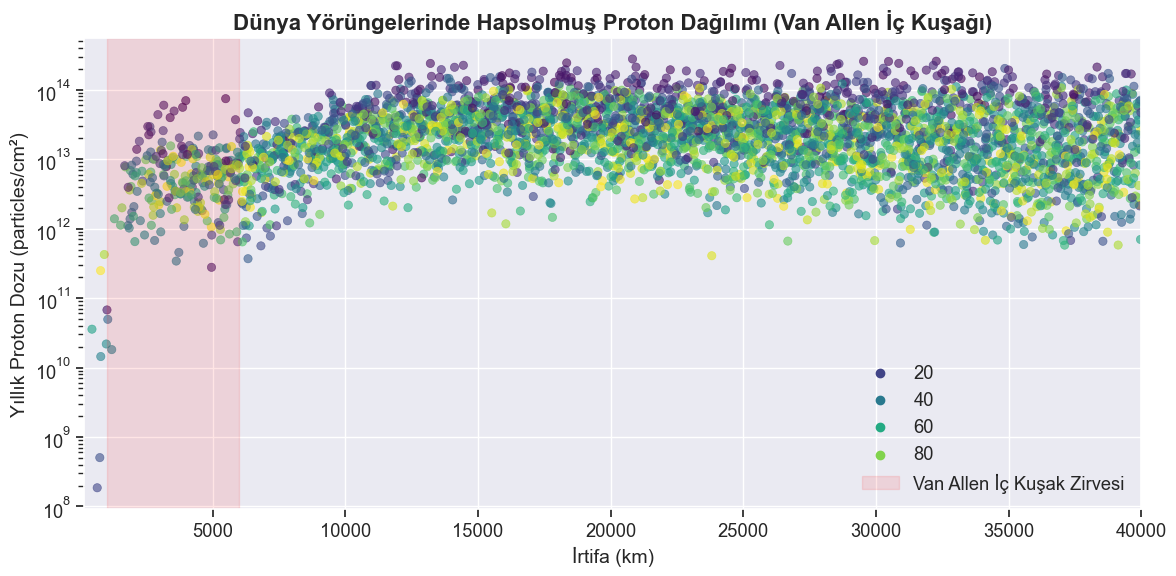

In [35]:
plt.figure(figsize=(12, 6))
# 10 MeV Trapped Protonların İrtifaya göre dağılımı
circular = df[df["eccentricity"] < 0.1]
sns.scatterplot(data=df, x='altitude_km', y='e_fluence_2.00MeV', 
                hue='inclination_deg', palette='viridis', alpha=0.6, edgecolor=None)

plt.title("Dünya Yörüngelerinde Hapsolmuş Proton Dağılımı (Van Allen İç Kuşağı)", fontsize=16, fontweight='bold')
plt.xlabel("İrtifa (km)", fontsize=14)
plt.ylabel("Yıllık Proton Dozu (particles/cm²)", fontsize=14)
plt.yscale('log') # Logaritmik ölçek fizikte şarttır
plt.xlim(150, 40000)
plt.axvspan(1000, 6000, color='red', alpha=0.1, label='Van Allen İç Kuşak Zirvesi')
plt.legend()
plt.tight_layout()
plt.show()

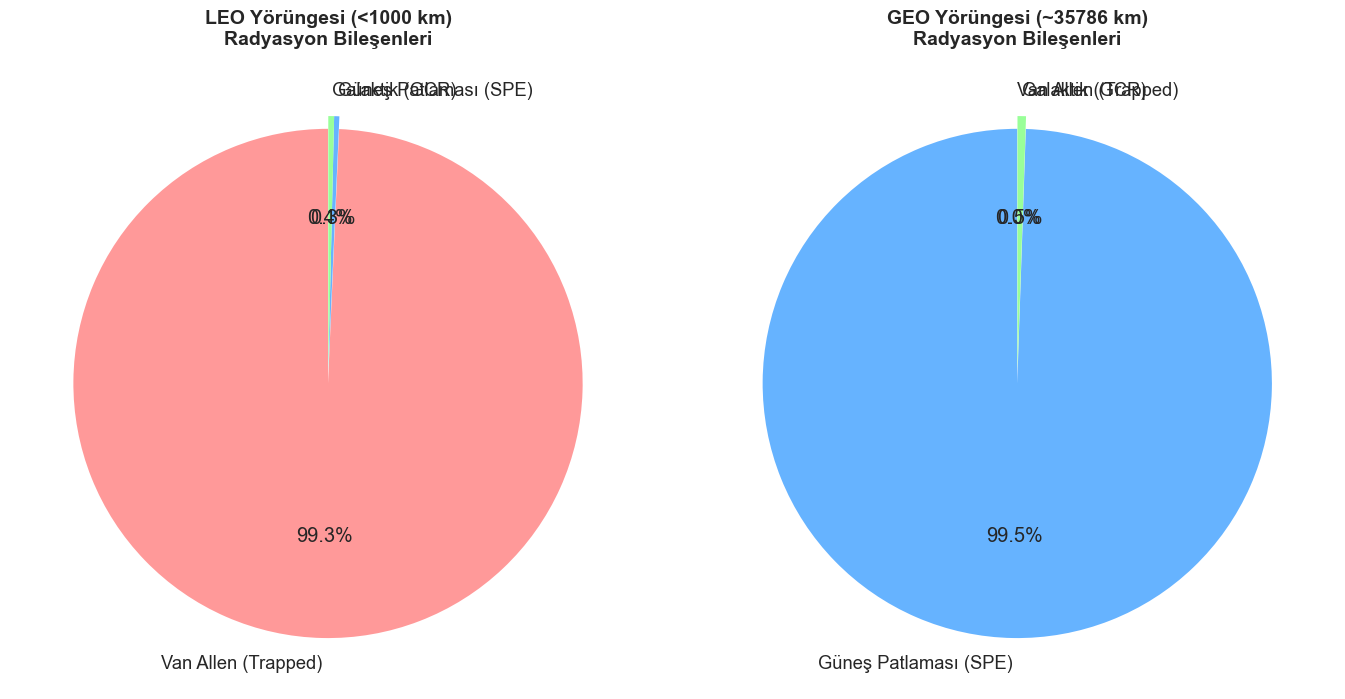

In [5]:
# LEO (Alçak Yörünge) ve GEO (Yer Senkron) için iki temsili alt küme alalım
leo_df = df[df['altitude_km'] < 1000].mean(numeric_only=True)
geo_df = df[(df['altitude_km'] > 35000) & (df['eccentricity'] < 0.1)].mean(numeric_only=True)

# Çizilecek bileşenler (10 MeV referans)
labels = ['Van Allen (Trapped)', 'Güneş Patlaması (SPE)', 'Galaktik (GCR)']
leo_sizes = [leo_df['p_trapped_fluence_10.0MeV'], leo_df['p_spe_fluence_10.0MeV'], leo_df['p_gcr_fluence_10.0MeV']]
geo_sizes = [geo_df['p_trapped_fluence_10.0MeV'], geo_df['p_spe_fluence_10.0MeV'], geo_df['p_gcr_fluence_10.0MeV']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# LEO Pasta
ax1.pie(leo_sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'], explode=(0.05, 0, 0))
ax1.set_title('LEO Yörüngesi (<1000 km)\nRadyasyon Bileşenleri', fontsize=14, fontweight='bold')

# GEO Pasta
ax2.pie(geo_sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'], explode=(0, 0.05, 0))
ax2.set_title('GEO Yörüngesi (~35786 km)\nRadyasyon Bileşenleri', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

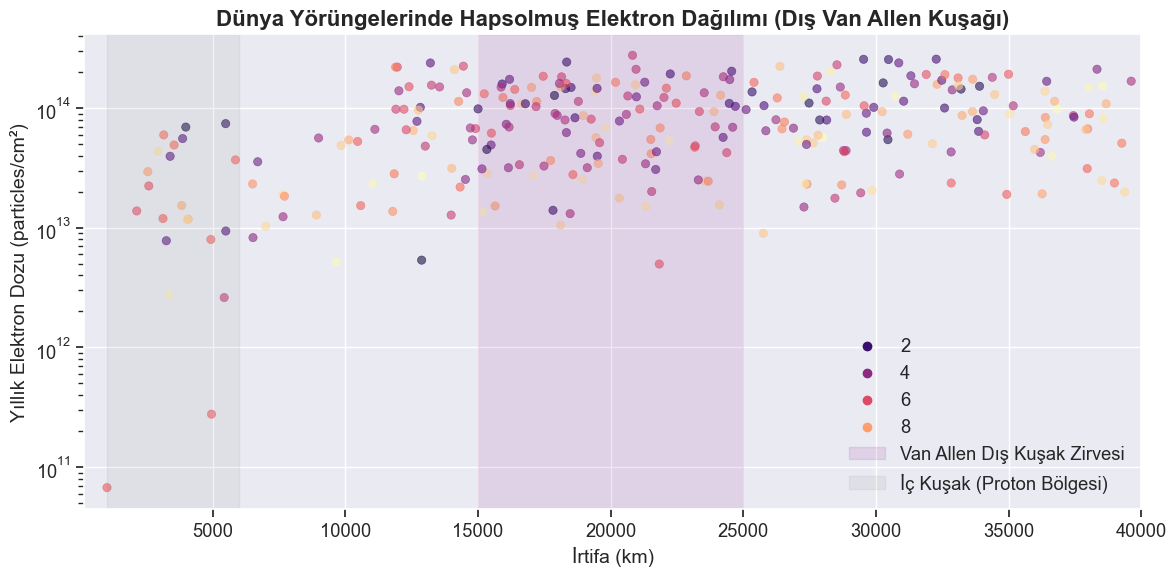

In [17]:
plt.figure(figsize=(12, 6))
# Elektronların (Örn: 2 MeV) İrtifaya göre dağılımı
# Not: Sütun adını kendi CSV'ndeki elektron sütunuyla değiştir (e_fluence_2.00MeV vb.)
incli = df[df["inclination_deg"] <= 10]
sns.scatterplot(data=incli, x='altitude_km', y='e_fluence_2.00MeV', 
                hue='inclination_deg', palette='magma', alpha=0.6, edgecolor=None)

plt.title("Dünya Yörüngelerinde Hapsolmuş Elektron Dağılımı (Dış Van Allen Kuşağı)", fontsize=16, fontweight='bold')
plt.xlabel("İrtifa (km)", fontsize=14)
plt.ylabel("Yıllık Elektron Dozu (particles/cm²)", fontsize=14)
plt.yscale('log')
plt.xlim(150, 40000)

# Elektronların yoğunlaştığı "Dış Kuşak" bölgesini vurgulayalım
plt.axvspan(15000, 25000, color='purple', alpha=0.1, label='Van Allen Dış Kuşak Zirvesi')
plt.axvspan(1000, 6000, color='gray', alpha=0.1, label='İç Kuşak (Proton Bölgesi)')

plt.legend()
plt.tight_layout()
plt.show()

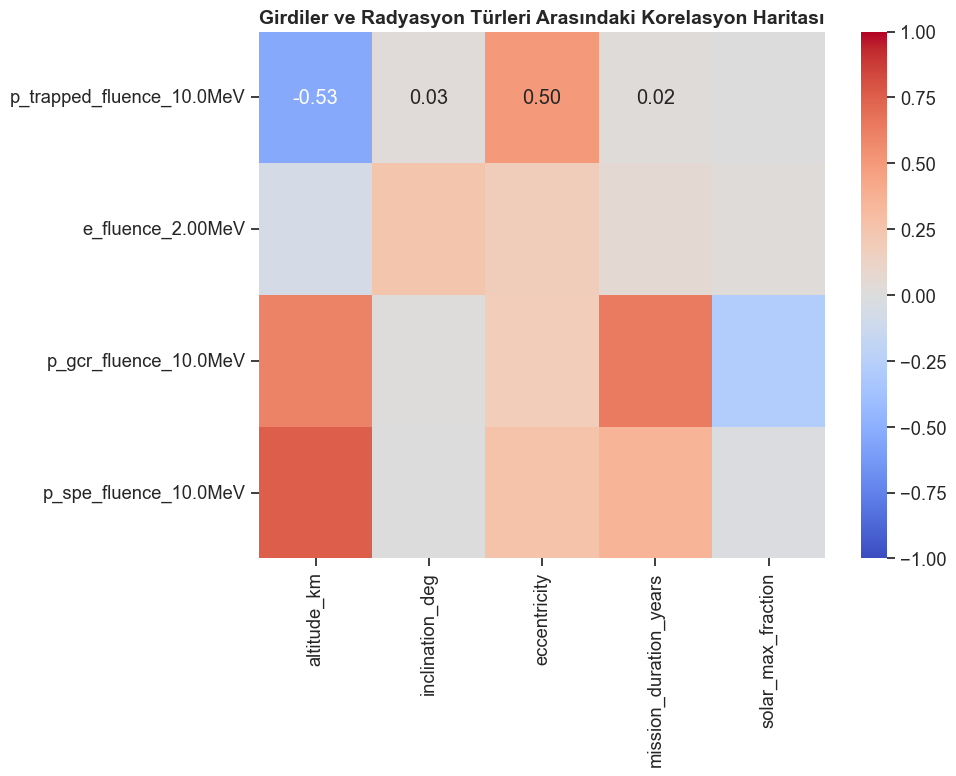

In [18]:
# Analiz edilecek Girdiler ve Çıktılar
features = ['altitude_km', 'inclination_deg', 'eccentricity', 'mission_duration_years', 'solar_max_fraction']
targets = ['p_trapped_fluence_10.0MeV', 'e_fluence_2.00MeV', 'p_gcr_fluence_10.0MeV', 'p_spe_fluence_10.0MeV']

# Tüm özellikleri ve hedefleri (hedef değerlerin logaritmasını alarak) birleştir
corr_df = df[features].copy()
for target in targets:
    corr_df[target] = np.log10(df[target] + 1e-5)

# Korelasyon Matrisi
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr().loc[targets, features], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Girdiler ve Radyasyon Türleri Arasındaki Korelasyon Haritası", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Model Eğitimi

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np

# 1. Özellikler (Features - X)
features = ['altitude_km', 'inclination_deg', 'eccentricity', 'mission_duration_years', 'solar_max_fraction']

# 2. Hedefler (Targets - Y) -> ELEKTRONLAR EKLENDİ!
# Not: Sizin CSV'de elektron sütunu tam olarak hangi enerjiyle kayıtlıysa (örn: e_fluence_2.00MeV veya 1.00MeV) buraya onu yazın.
targets = [
    'p_trapped_fluence_10.0MeV',  # İç kuşak tehlikesi
    'e_fluence_2.00MeV',          # Dış kuşak tehlikesi (Trapped Elektronlar)
    'p_gcr_fluence_10.0MeV',      # Galaktik arka plan
    'p_spe_fluence_10.0MeV'       # Güneş patlamaları
]

X = df[features]
# 0 logaritmasını önlemek için küçük bir epsilon ekliyoruz
Y = np.log10(df[targets] + 1e-5) 

# 3. Veri Setini Bölme (%80 Eğitim, %20 Test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Multi-Output Random Forest Modelini Kur ve Eğit
print("4 Çıktılı Yapay Zeka Modeli Eğitiliyor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, Y_train)

# 5. Test ve Değerlendirme
Y_pred = rf_model.predict(X_test)

print("\n--- Model Performansı (R² Skorları) ---")
for i, target in enumerate(targets):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"{target}: {r2:.4f}")

# Modeli Aşama 2 (Kalkan Malzemesi Algoritması) için kaydet
joblib.dump(rf_model, 'space_radiation_rf_model_v4.pkl')
print("\nModel başarıyla eğitildi ve kaydedildi!")

4 Çıktılı Yapay Zeka Modeli Eğitiliyor...

--- Model Performansı (R² Skorları) ---
p_trapped_fluence_10.0MeV: 0.8798
e_fluence_2.00MeV: 0.7236
p_gcr_fluence_10.0MeV: 0.9320
p_spe_fluence_10.0MeV: 0.9886

Model başarıyla eğitildi ve kaydedildi!


In [23]:
%pip install --upgrade scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=1.24.1 from https://files.pythonhosted.org/packages/76/1d/edccf27adedb754db7c4511d5eac8b83f004ae948fe2d3509e8b78097d4c/numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB 653.6 kB/s eta 0:00:13
   ---------------------------------------- 0.1/8.1 MB 558.5 kB/s eta 0:00:15
   ---------------------------------------- 0.1/8.1 MB 655.4 kB/s eta 0:

ERROR: Could not install packages due to an OSError: [WinError 5] Erişim engellendi: 'C:\\Users\\volka\\AppData\\Roaming\\Python\\Python311\\site-packages\\~umpy\\.libs\\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll'
Consider using the `--user` option or check the permissions.



In [25]:
import sklearn
print(sklearn.__version__)

1.3.0


In [27]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import joblib

X = df[features]
Y = np.log10(df[targets] + 1e-5)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Yarışacak Modeller
model_zoo = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=7, learning_rate=0.1, random_state=42)
}

best_models = {}

print("--- FİZİKSEL BİLEŞENLERE ÖZEL MODEL OPTİMİZASYONU ---\n")

for i, target in enumerate(targets):
    print(f"Hedef: {target}")
    best_score = -1
    best_name = ""
    
    y_tr = Y_train.iloc[:, i]
    y_te = Y_test.iloc[:, i]
    
    for model_name, model in model_zoo.items():
        # Modeli bu spesifik hedef için eğit
        # Not: Gradient Boosting Multi-Output desteklemez, o yüzden tek tek eğitiyoruz (Tam senin istediğin gibi!)
        model.fit(X_train, y_tr)
        preds = model.predict(X_test)
        score = r2_score(y_te, preds)
        
        print(f"  {model_name} R² Skoru: {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_name = model_name
            # En iyi modeli sakla
            best_models[target] = model
            
    print(f"  🏆 KAZANAN MODEL: {best_name} (R² = {best_score:.4f})\n")

# Kazanan modelleri kaydet
joblib.dump(best_models, 'optimized_radiation_models_dict.pkl')
print("Her çıktı için en iyi modeller 'optimized_radiation_models_dict.pkl' sözlüğü olarak kaydedildi!")

--- FİZİKSEL BİLEŞENLERE ÖZEL MODEL OPTİMİZASYONU ---

Hedef: p_trapped_fluence_10.0MeV
  Random Forest R² Skoru: 0.8823
  Gradient Boosting R² Skoru: 0.8724
  🏆 KAZANAN MODEL: Random Forest (R² = 0.8823)

Hedef: e_fluence_2.00MeV
  Random Forest R² Skoru: 0.7235
  Gradient Boosting R² Skoru: 0.7164
  🏆 KAZANAN MODEL: Random Forest (R² = 0.7235)

Hedef: p_gcr_fluence_10.0MeV
  Random Forest R² Skoru: 0.9977
  Gradient Boosting R² Skoru: 0.9981
  🏆 KAZANAN MODEL: Gradient Boosting (R² = 0.9981)

Hedef: p_spe_fluence_10.0MeV
  Random Forest R² Skoru: 0.9991
  Gradient Boosting R² Skoru: 0.9993
  🏆 KAZANAN MODEL: Gradient Boosting (R² = 0.9993)

Her çıktı için en iyi modeller 'optimized_radiation_models_dict.pkl' sözlüğü olarak kaydedildi!
